### Data Exploration

In [1]:
# Import
import geopandas as gpd
from sqlalchemy import create_engine
from db_connection_test import user, pwd, host, port, database
import matplotlib.pyplot as plt

import sys
import os

sys.path.append(os.path.abspath("../src"))

Connection established.


In [2]:
# Quering the database
engine_for_connection = create_engine(f'postgresql://{user}:{pwd}@{host}:{port}/{database}')

query = """
SELECT id, geom, highway
FROM roads
"""

geo_df = gpd.read_postgis(
    query,
    engine_for_connection,
    geom_col="geom"
)



In [3]:
# Dataframe columns renaming and definition
geo_df = geo_df.rename(columns={'highway': 'road_type'})
geo_df_metric = geo_df.to_crs(epsg=32632)
geo_df_metric['length_km'] = geo_df_metric['geom'].length / 1000

In [4]:
# Insights on data types
geo_df_metric.dtypes 

id              int64
geom         geometry
road_type         str
length_km     float64
dtype: object

In [5]:
# Lenght Statistic
print("Statistics on Roads Length (km): ")
print(geo_df_metric['length_km'].describe())

Statistics on Roads Length (km): 
count    34387.000000
mean         0.094356
std          0.145988
min          0.000178
25%          0.017434
50%          0.044165
75%          0.110171
max          2.914613
Name: length_km, dtype: float64


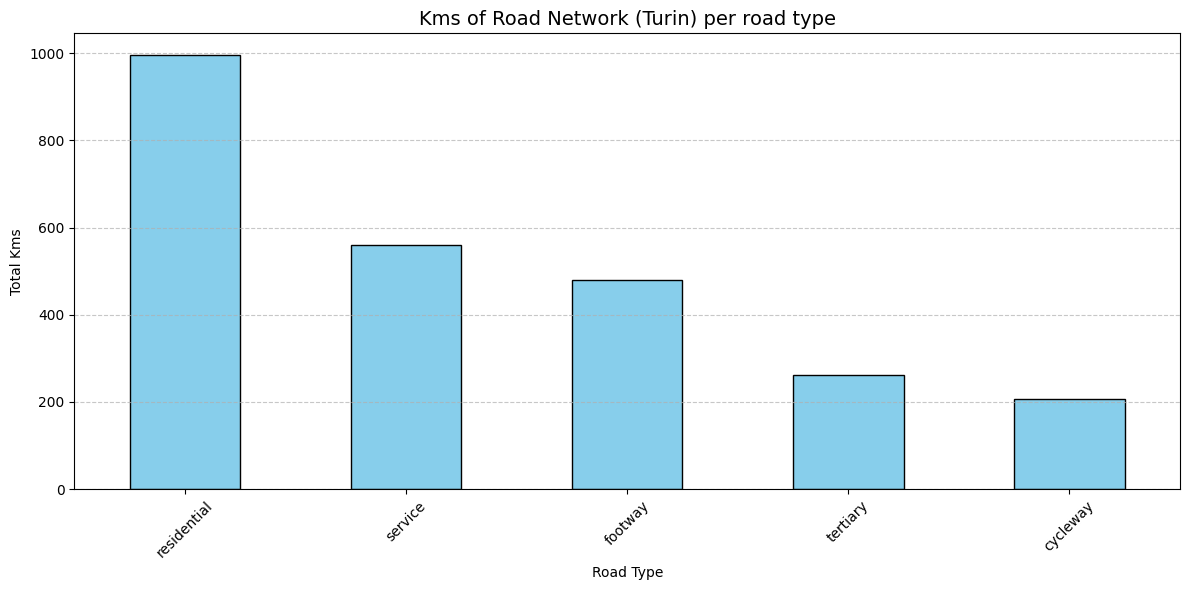

In [6]:
# Road type Statistic
stats = geo_df_metric.groupby('road_type')['length_km'].sum().sort_values(ascending=False)
plt.figure(figsize=(12, 6))
stats.head(5).plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Kms of Road Network (Turin) per road type', fontsize=14)
plt.ylabel('Total Kms')
plt.xlabel('Road Type')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Remark 1: The graph highlights the urban hierarchy: residential streets form the backbone of the city, while primary, secondary, and tertiary roads comprise the supporting network.

Remark 2: A high percentage of the road network consists of "service" and "footway" roads, which do not affect traffic flows. When attention is devoted to the road traffic congestion, these road types can be filtered out.

In [7]:
# Filtering out roads of types "service" and "footway"
geo_df_metric_filtered = geo_df_metric.loc[lambda x: (x['road_type'] != "service") & (x['road_type'] != "footway")]
geo_df_metric_filtered

,id,geom,road_type,length_km
0,10582,"LINESTRING (394967.082 4991836.908, 394969.411...",steps,0.005181
10,19148,"LINESTRING (399195.95 4998514.896, 399213.822 ...",track,0.020164
12,20346,"LINESTRING (396761.779 4989532.863, 396738.009...",steps,0.024838
16,21369,"LINESTRING (395664.339 4987475.24, 395656.114 ...",steps,0.008722
17,21593,"LINESTRING (398367.431 4991611.243, 398411.414...",path,0.045073
...,...,...,...,...
34368,34369,"LINESTRING (399369.044 4997172.442, 399370.46 ...",unclassified,0.023082
34377,34378,"LINESTRING (398957.893 4996927.237, 398968.923...",steps,0.013044
34378,34379,"LINESTRING (398970.45 4996922.793, 398960.564 ...",steps,0.012217
34382,34383,"LINESTRING (399317.92 4997114.97, 399305.095 4...",steps,0.012831


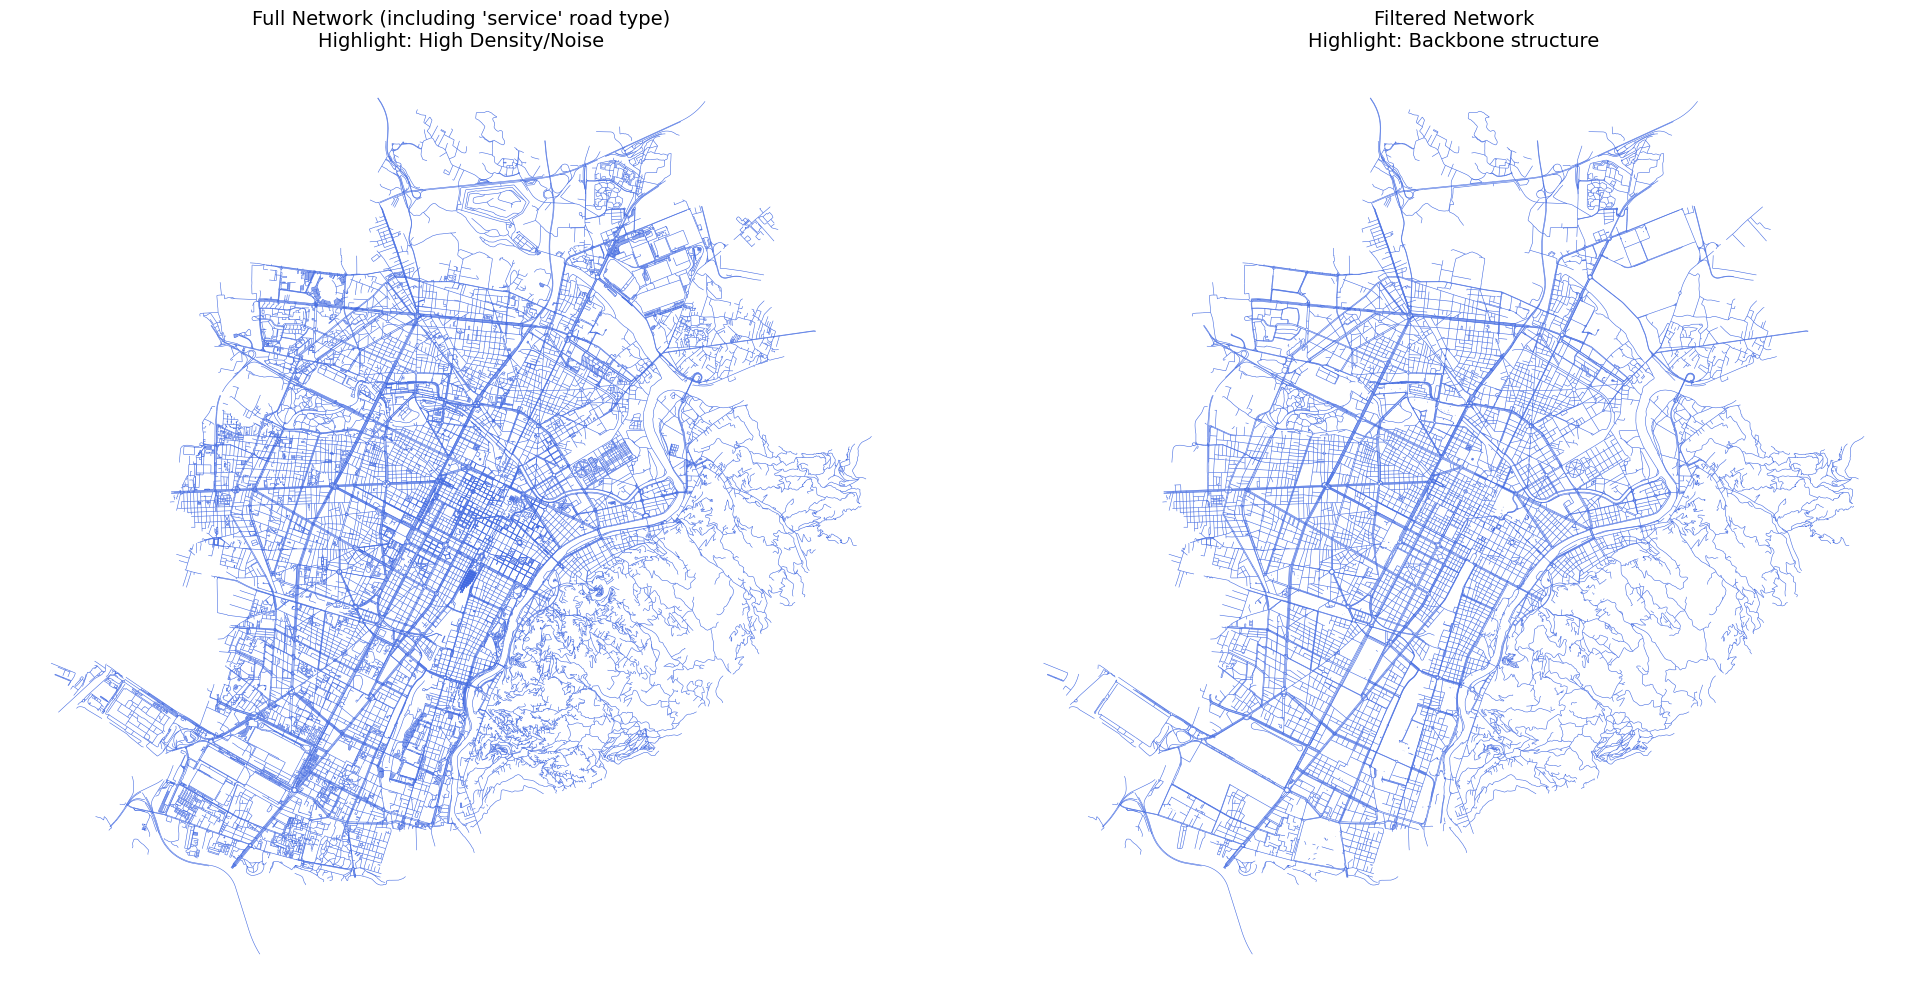

In [8]:
import matplotlib.pyplot as plt

# Building one figure with two subplots (1 row, 2 columns)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

# Full Network
geo_df_metric.plot(ax=ax1, color='royalblue', linewidth=0.4)
ax1.set_title("Full Network (including 'service' road type)\nHighlight: High Density/Noise", fontsize=14)
ax1.axis('off')

# Filtered Network
geo_df_metric_filtered.plot(ax=ax2, color='royalblue', linewidth=0.4)
ax2.set_title("Filtered Network\nHighlight: Backbone structure", fontsize=14)
ax2.axis('off')

plt.tight_layout()
plt.show()

In [13]:
# Analysis of the comparison
perc_num_roads_removed = (geo_df_metric.shape[0] - geo_df_metric_filtered.shape[0]) / geo_df_metric.shape[0] * 100
print(f"Filtering out the “service” road type reduces the \ntotal number of segments by approximately {perc_num_roads_removed}%, \nremoving unnecessary data that represent, for example, dead ends, \nparking areas, or inaccessible areas.")

Filtering out the “service” road type reduces the 
total number of segments by approximately 42.67601128333382%, 
removing unnecessary data that represent, for example, dead ends, 
parking areas, or inaccessible areas.


In [10]:
geo_df_metric_filtered

,id,geom,road_type,length_km
0,10582,"LINESTRING (394967.082 4991836.908, 394969.411...",steps,0.005181
10,19148,"LINESTRING (399195.95 4998514.896, 399213.822 ...",track,0.020164
12,20346,"LINESTRING (396761.779 4989532.863, 396738.009...",steps,0.024838
16,21369,"LINESTRING (395664.339 4987475.24, 395656.114 ...",steps,0.008722
17,21593,"LINESTRING (398367.431 4991611.243, 398411.414...",path,0.045073
...,...,...,...,...
34368,34369,"LINESTRING (399369.044 4997172.442, 399370.46 ...",unclassified,0.023082
34377,34378,"LINESTRING (398957.893 4996927.237, 398968.923...",steps,0.013044
34378,34379,"LINESTRING (398970.45 4996922.793, 398960.564 ...",steps,0.012217
34382,34383,"LINESTRING (399317.92 4997114.97, 399305.095 4...",steps,0.012831


In [11]:
# Saving clean table in DB
geo_df_metric_filtered.to_postgis(
    name="roads_filtered",
    con=engine_for_connection,
    schema="public",     # specifying schema
    if_exists="replace",
    index=False
    )